In [1]:
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models("vision_text")
benchmarks = ['fungi_tastic_2025']
outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


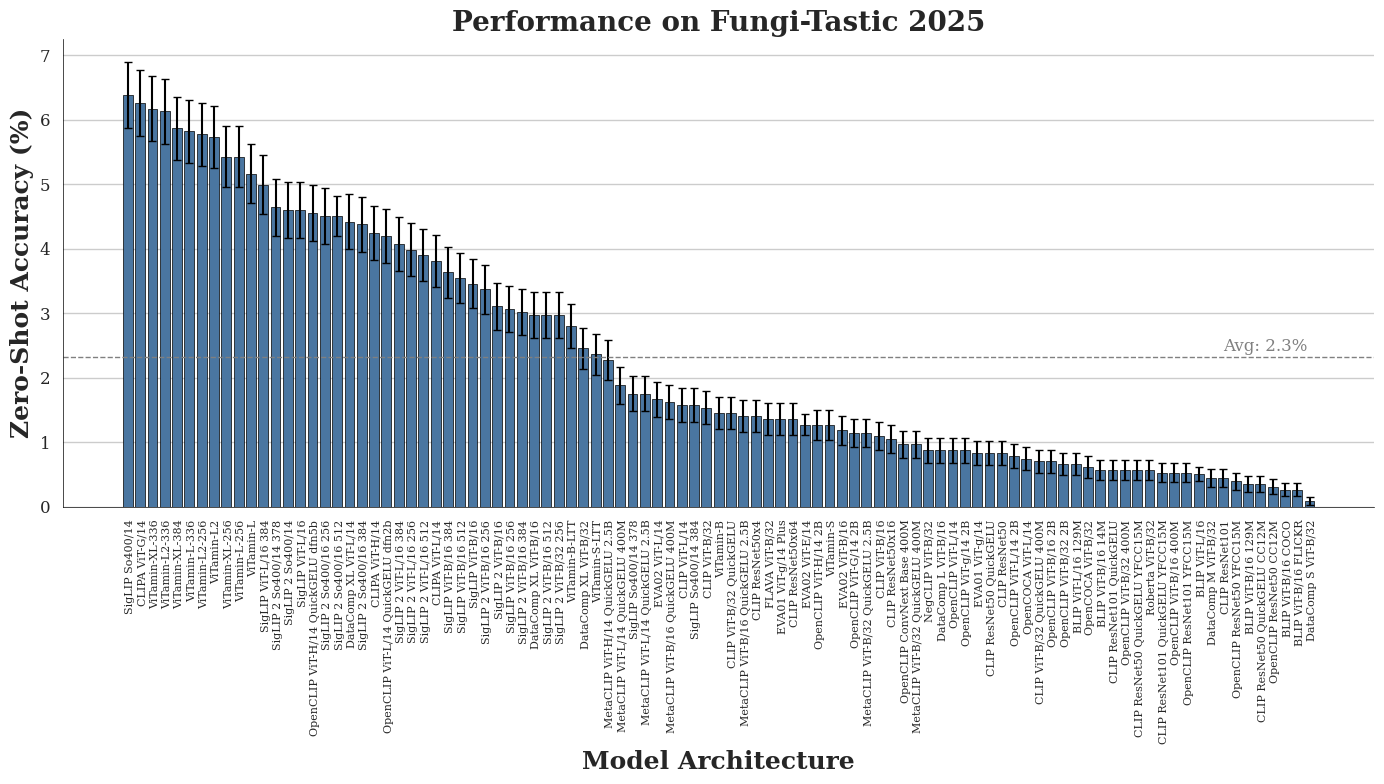

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 8
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12
BAR_COLOR = "#3b76af"

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': .5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    color=BAR_COLOR,
    edgecolor='black',
    linewidth=.5
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on Fungi-Tastic 2025', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.6 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 0.1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

# Save to file
# plt.savefig("fungi_tastic_barplot.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [3]:
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models("vision_text")
benchmarks = ['imagenet1k']
outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

In [4]:
len(results['model_name'].unique())

97

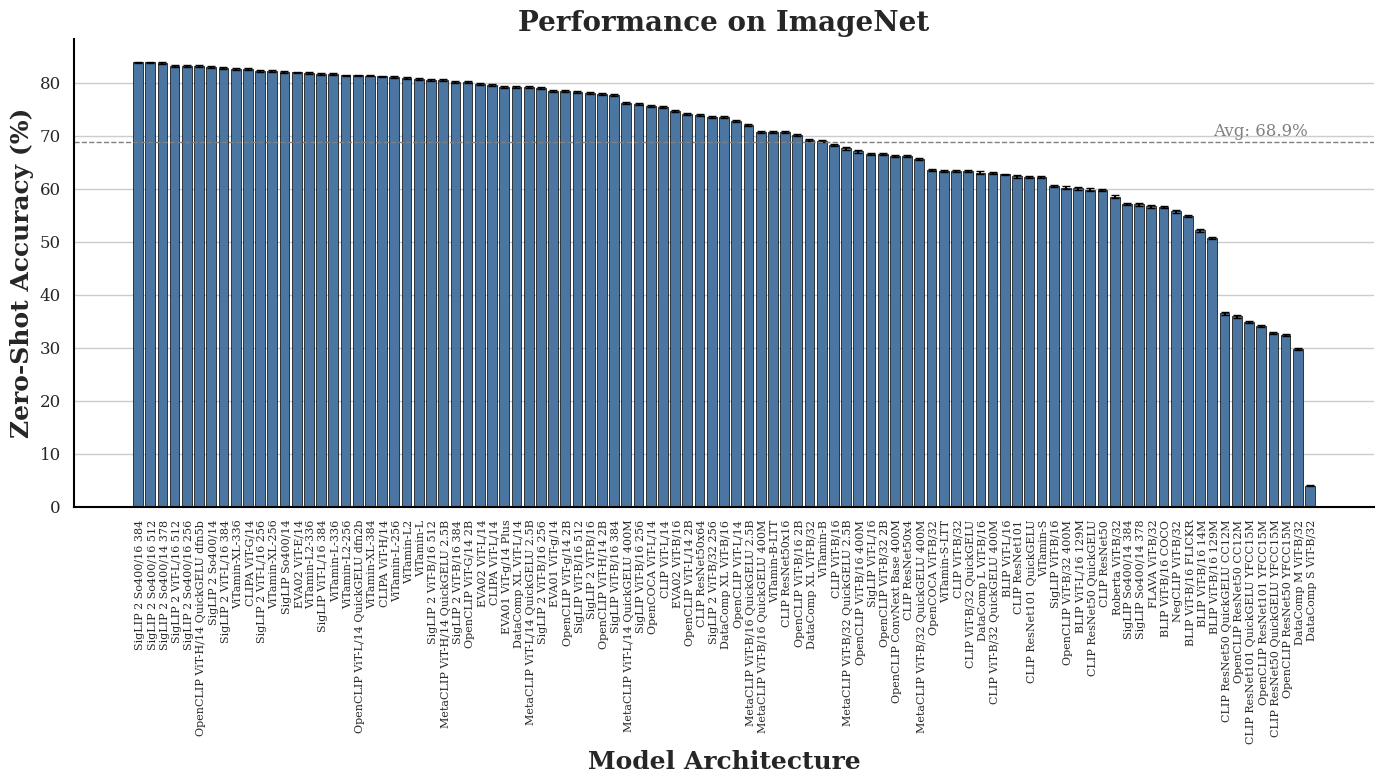

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 8
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12
BAR_COLOR = "#3b76af"

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    color=BAR_COLOR,
    edgecolor='black',
    linewidth=0.5,
    
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on ImageNet', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.6 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

# Save to file
# plt.savefig("fungi_tastic_barplot.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [6]:
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models("vision_text")
benchmarks = ['imagenet1k']
outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings


model_mappings = get_model_mappings('year')
results['year'] = results["model_name"].map(model_mappings)
model_mappings = get_model_mappings('month')
results['month'] = results["model_name"].map(model_mappings)
# model_mappings = get_model_mappings('name')
# results['model_name'] = results["model_name"].map(model_mappings)

KeyError: 'year'

In [ ]:
len(results.model_name.unique())

98

/tmp/ipykernel_3261832/804206594.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_3261832/804206594.py:44: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


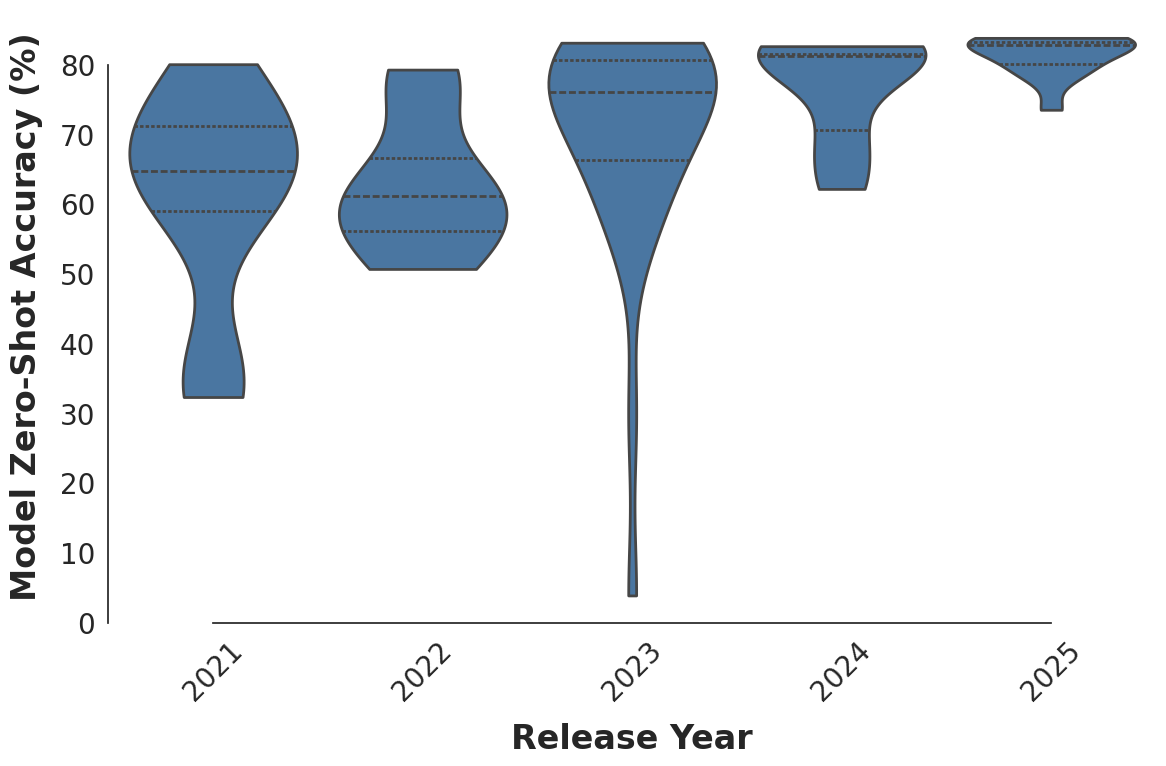

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Custom font sizes and styling
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 20
LINE_WIDTH = 4
MARKER_SIZE = 12

# Create a time column combining year and month 
results['time'] = results['year'].astype(str) + '-' + results['month'].astype(str).str.zfill(2)

# Calculate average performance per model by time
time_perf = results.groupby(['model_name'])['correctness'].mean().reset_index()

# Join with time information (taking first occurrence of each model)
model_times = results.drop_duplicates('model_name')[['model_name', 'time', 'year', 'month']]
time_perf = time_perf.merge(model_times, on='model_name')

# Convert performance to percentage
time_perf['performance'] = time_perf['correctness'] * 100

# Sort by time
time_perf['time_sort'] = time_perf['year'] * 100 + time_perf['month'].astype(int)
time_perf = time_perf.sort_values('time_sort')
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Custom font sizes and styling
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 20

# Apply theme
sns.set_theme(style="white", font_scale=1.5)

# Create figure
plt.figure(figsize=(12, 8))

# Plot violin plot
ax = sns.violinplot(
    data=time_perf,
    x='year',
    y='performance',
    inner="quartile",
    linewidth=2,
    cut=0,
    scale='width',
    palette=["#3b76af"] * time_perf['year'].nunique()
)

# Axis labels
ax.set_xlabel("Release Year", fontsize=LABEL_FONT_SIZE, labelpad=12)
ax.set_ylabel("Model Zero-Shot Accuracy (%)", fontsize=LABEL_FONT_SIZE, labelpad=12)

# Ticks formatting
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE, length=6, width=1)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)

# Style adjustments
sns.despine(trim=True)
ax.grid(False)

# Tight layout and save
plt.tight_layout()
# plt.savefig("imagenet_violin_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()



In [ ]:
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models("vision_text")
benchmarks = ['fungi_tastic_2025']
outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings


model_mappings = get_model_mappings('year')
results['year'] = results["model_name"].map(model_mappings)
model_mappings = get_model_mappings('month')
results['month'] = results["model_name"].map(model_mappings)
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

75

/tmp/ipykernel_3261832/2048448029.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_3261832/2048448029.py:45: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


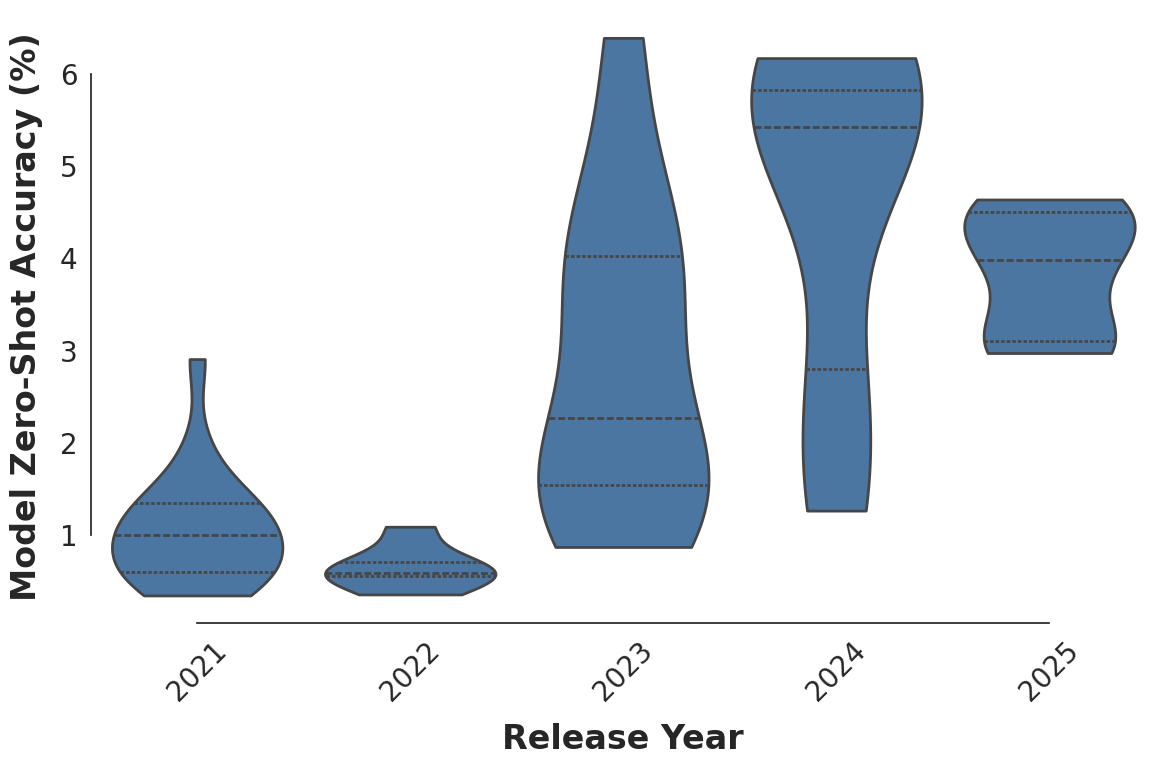

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Custom font sizes and styling
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 20
LINE_WIDTH = 4
MARKER_SIZE = 12

# Create a time column combining year and month 
results['time'] = results['year'].astype(str) + '-' + results['month'].astype(str).str.zfill(2)

# Calculate average performance per model by time
time_perf = results.groupby(['model_name'])['correctness'].mean().reset_index()

# Join with time information (taking first occurrence of each model)
model_times = results.drop_duplicates('model_name')[['model_name', 'time', 'year', 'month']]
time_perf = time_perf.merge(model_times, on='model_name')

# Convert performance to percentage
time_perf['performance'] = time_perf['correctness'] * 100

# Sort by time
time_perf['time_sort'] = time_perf['year'] * 100 + time_perf['month'].astype(int)
time_perf = time_perf.sort_values('time_sort')

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Custom font sizes and styling
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 20

# Apply theme
sns.set_theme(style="white", font_scale=1.5)

# Create figure
plt.figure(figsize=(12, 8))

# Plot violin plot
ax = sns.violinplot(
    data=time_perf,
    x='year',
    y='performance',
    inner="quartile",
    linewidth=2,
    cut=0,
    scale='width',
    palette=["#3b76af"] * time_perf['year'].nunique()
)

# Axis labels
ax.set_xlabel("Release Year", fontsize=LABEL_FONT_SIZE, labelpad=12)
ax.set_ylabel("Model Zero-Shot Accuracy (%)", fontsize=LABEL_FONT_SIZE, labelpad=12)

# Ticks formatting
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE, length=6, width=1)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)

# Style adjustments
sns.despine(trim=True)
ax.grid(False)

# Tight layout and save
plt.tight_layout()
# plt.savefig("imagenet_violin_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()

